## Q.1. Determinant of a Square Matrix ##

- Write a function `submatrix(A,i,j)` that takes a square matrix $A \in  Z^{n\times n}$, and a row
number $i$ and a column number $j$ as parameters $(0 \le i, j \le n − 1)$ as parameters and
returns the submatrix of $A$ obtained by deleting the $i$th row and $j$th column of the
matrix $A$.

In [1]:
from numpy import *

In [2]:
def submatrix(A,i,j):
    S1=A[:i,:j]
    S2=A[:i,j+1:]
    S3=A[i+1:,:j]
    S4=A[i+1:,j+1:]
    Submat=block([[S1,S2],[S3,S4]])
    return Submat

- Write a function `determinant(A)` that takes a square matrix $A \in Z^{n\times n} $as parameter
and returns the determinant of the matrix.
The determinant is defined recursively as follows:
- If $n = 1$, then $det($A$) = a_{00}$.
- If $n > 1$, then
$det(A) =\sum_{j=0}^{n-1}(-1)^j a_{0j}\ det(M_{0j})$\
where $M_{0j}$ is the $(n − 1) \times (n − 1)$ matrix obtained by deleting the $0$ th row and
the $j$ th column of $A$.
You may use the function `submatrix(A)` to compute the matrix $M_{0j}$

In [3]:
def determinant(A):
    if A.shape[0]!=A.shape[1]:
        print("Determinant only for square matrix!!")
    if A.shape[0]==1:
        return A[0][0]
    else:
        Sum=0
        for j in range(A.shape[0]):
            M_Oj=submatrix(A,0,j)
            Sum+=(-1)**j*A[0][j]*determinant(M_Oj)
        return Sum

In [4]:
n=int(input("Enter the no of rows for the square matrix A"))
L=[int(x) for x in input(f"Enter the {n*n} elements rowwise").split(",")]

Enter the no of rows for the square matrix A 3
Enter the 9 elements rowwise 1,2,3,0,4,5,1,0,6


In [5]:
M=array(L)
M1=M.reshape(3,3)
print("Input matrix M:\n",M1)
print("Determinant for the matrix M:",determinant(M1))

Input matrix M:
 [[1 2 3]
 [0 4 5]
 [1 0 6]]
Determinant for the matrix M: 22


## Q.2 Matrix with a special property ##

- Write a function `pairwise_distance(P)` that takes a $n$ sized list of points (a point is a pair
$(x_i, y_i)$) in the $2D$ plane as parameter and returns a matrix of size $n\times n$ with their pairwise
distances.
The distance between two points $(x_i, y_i)$ and $(x_j , y_j)$ is defined as:
$d(i, j) = \sqrt{(x_i − x_j)^2 + (y_i − y_j)^2}$
You should not have any print statement inside the function.

In [6]:
import math as m 
def pairwise_distance(P):
    D=zeros((len(P),len(P)),float)
    for i in range(len(P)):
        for j in range(len(P)):
            d_ij=m.sqrt(((P[i][0]-P[j][0])**2 + (P[i][1]-P[j][1])**2))
            D[i][j]=round(float(d_ij),2)
    return D          

- Your program should take a number $n$, followed by a list of $2n$ integers as input, create a
$n$ sized list of pairs of points from it and output a matrix of $n\times n$ where the $(i, j)$-th entry
represents the distance between the $i$-th and $j$-th points.

In [7]:
n=int(input("Enter the number"))
L=[int(x) for x in input(f"Enter {2*n} integers separated by comma").split(",")]
pair_L=[(L[i],L[i+1]) for i in range(0,len(L),2)]
print(pair_L)
print("The required matrix:\n" ,pairwise_distance(pair_L))

Enter the number 3
Enter 6 integers separated by comma 0,0,3,4,6,8


[(0, 0), (3, 4), (6, 8)]
The required matrix:
 [[ 0.  5. 10.]
 [ 5.  0.  5.]
 [10.  5.  0.]]


## Q.3. Working with PGM file ##

- Write a function `write_to_pgm` that takes a numpy $2D$ array $M$ and a file name $f$ as
parameters, and creates a pgm file with the name $f$ from the matrix $M$. The format
of a pgm file is given below:
    - Sample pgm f i l e :
        - P2
        - 4 2 ( number o f columns f o l l owed by number o f rows )
        - 255 (maximum value o f a p i x e l in the image )
        - 10 255 200 90
        - 255 255 10 90

In [12]:
def write_to_pgm(M,f):
    row,col=M.shape[0],M.shape[1]
    with open(f,"w") as fo:
        fo.write("P2")
        fo.write("\n")
        fo.write(str(col) + " "+str(row))
        fo.write("\n")
        fo.write(str(255)+"\n")
        for rows in M:
            for mem in rows:
                fo.write(str(int(mem)))
                fo.write(" ")
            fo.write("\n")

- Use the function `read_pgm` (that was taught in class) that takes a file name as input
and returns a $2D$ numpy array.

In [13]:
import numpy as np
def read_pgm(filename):
    with open(filename, 'r') as f:
        assert f.readline().strip() == 'P2'

        line = f.readline()
        while line.startswith('#'):
            line = f.readline()

        width, height = map(int, line.split())
        maxval = int(f.readline())

        pixels = []
        for line in f:
            pixels.extend(map(int, line.split()))

        img = np.array(pixels).reshape((height, width))
        return img

- Write a function `mirror_left_right` that takes an input filename f1 and an output
file name f2 as parameters and does the following: Uses`read_pgm` to read f1 and
convert to a $2D$ array, then flip the image **horizontally**, and writes it to f2 using the
`write_to_pgm` function.

In [18]:
import matplotlib.pyplot as plt
def mirror_left_right(f1,f2):
    M=read_pgm(f1)
    plt.imshow(M, cmap="gray")
    plt.axis("off")
    plt.show()
    M_img= M[:,::-1]
    plt.imshow(M_img, cmap="gray")
    plt.axis("off")
    plt.show()
    write_to_pgm(M_img,f2)

- Your main program should ask for two filenames, read the first file, call the `mirror_left_right`
function and writes the output to the second file. You should not have any print statement
inside the function.

Enter the input pgm filename: C:/Users/SURAJIT/LAB_EXERCISES (ID1110)/dragon_ascii.pgm
Enter the output pgm filename: dragon_rotated.pgm


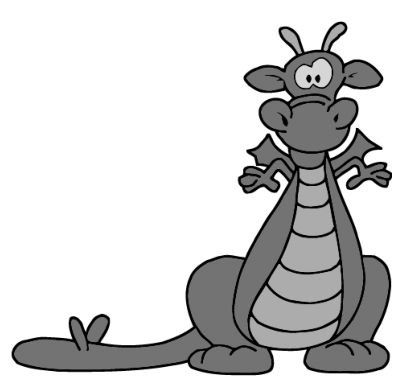

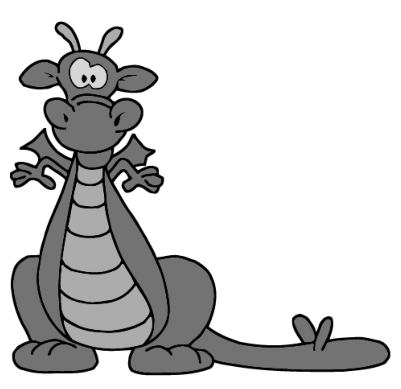

In [19]:
f1=input("Enter the input pgm filename:")
f2=input("Enter the output pgm filename:")
mirror_left_right(f1,f2)

- **Remark:** I need to pass the complete file path, not just the file name (e.g., `dragon_ascii.pgm`). This is because the file must be located relative to the current working directory, which in my case is `C:/Users/SURAJIT/LAB_EXERCISES (ID1110)`.

## Q.4. Working with PGM file ##

- Write a function `merge_pgm` that takes an input file name $f_1$ and an output filename $f_2$ as
parameters and creates $f_2$ which consisting of two side by side versions of image $f_1$ arranged
in a $2\times 2$ grid, where the first part is $f_1$ and the second part is a **left-right mirrored version**
of $f_1$. You have to do the following:
    - First read file $f_1$ into a $2D$ array $M$. Suppose the dimension of $M$ is $m\times n$, using the
    `read_pgm` function defined earlier.
    - Create a new array $P$ of size $m \times 2n$, where the left $m \times n$ subarray will contain the
    original array $M$ and the right $m \times n$ subarray will contain the **left-right-mirrored**
    version of the array.
    - Write the new array $P$ into the output pgm file $f_2$ using the function `write_to_pgm`.

In [22]:
def merge_pgm(f1,f2):
    M=read_pgm(f1)
    m,n=M.shape[0],M.shape[1]
    P=np.zeros((m,2*n),dtype=int)
    for i in range(m):
        for j in range(n):
            P[i][j]=M[i][j]
    for i in range(m):
        for j in range(n):
            P[i][n+j]=M[i][n-1-j]
    write_to_pgm(P,f2)

- Your main program asks for two file names, then calls the `merge_pgm` function to create a
merged version of the first file and writing the output to the second file. You should not
have any print statement inside the function.

In [23]:
f1=input("Enter the input pgm filename:")
f2=input("Enter the output pgm filename:")
merge_pgm(f1,f2)    

Enter the input pgm filename: C:/Users/SURAJIT/LAB_EXERCISES (ID1110)/dragon_ascii.pgm
Enter the output pgm filename: dragon_tworotated.pgm


**Bonus: Visualization**

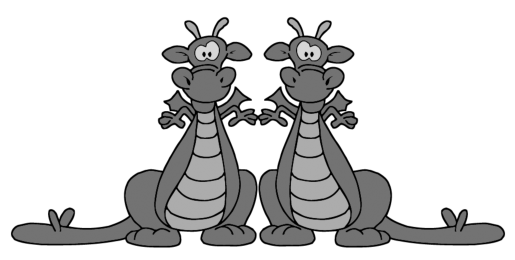

In [25]:
M_Rot=read_pgm("C:/Users/SURAJIT/LAB_EXERCISES (ID1110)/dragon_tworotated.pgm")
plt.imshow(M_Rot, cmap="gray")
plt.axis("off")
plt.show()